# Neural Net Code | CogSci 131 - Spring 2026
Moving from a perceptron to a neural net is a matter of judging outputs on a metric between 0 and 1. *If* the activation of a neuron is necessary for a "correct" output, *then* adjust the weights leading to that neuron from the input(s) to stimulate activation.

In [454]:
# Install Dependencies (You may need to restart after this process is complete)
%pip install numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


## Part 1 - Basic Neural Net Structure
The code below aims to display how a neural net (physically) works through code and how we can initiate "learning" with said neural net.

In [455]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import time


class Neural_Network(object):
    def __init__(self, func='sig', hidden:list=[3]):
        if isinstance(hidden, int):
            hidden = [hidden]
        elif not isinstance(hidden, list):
            hidden = list(hidden)
        
        for value in hidden:
            if not isinstance(value, int):
                raise ValueError("Hidden node count(s) parameter contains non-int values")
        
        # Neural Net Structure Parameters
        self.inputLayerSize  = 2
        self.hiddenLayerSizes = hidden   # List of hidden layer node counts (default = [3]) | hidden_layer_1 = 3 nodes
        self.outputLayerSize = 1
        
        # Randomly Generate Weight matricies
        self.W = [np.random.rand(self.inputLayerSize, self.hiddenLayerSizes[0]).astype(np.float32)]
        if len(self.hiddenLayerSizes) > 1:
            self.W.extend([np.random.rand(self.hiddenLayerSizes[i-1], self.hiddenLayerSizes[i]).astype(np.float32)
                      for i in range(1, len(self.hiddenLayerSizes))])
        self.W.append(np.random.rand(self.hiddenLayerSizes[-1], self.outputLayerSize).astype(np.float32))
        
        # Model's Function Type (default='sig')
            # "Hidden" is for computations to (forwawrd) and from (backward) a hidden node
        match func:
            case 'sig':
                self.funcFP = self.sigmoid
                self.funcBP = self.sigmoidPrime
                self.funcFP_hidden = self.sigmoid
                self.funcBP_hidden = self.sigmoidPrime
            case 'relu':
                self.funcFP = self.sigmoid
                self.funcBP = self.sigmoidPrime
                self.funcFP_hidden = self.relu
                self.funcBP_hidden = self.reluPrime
            case _:
                raise ValueError("Unavailable function selection")
        
        # Results
        self.costs = []
        self.accuracy = 1
        
    def forward(self, X) -> None:
        self.Z = []
        self.A = []
        # Propogate inputs through network
        for i in range(len(self.W)):
            # Z population
            if i == 0:
                self.Z.append(np.dot(X, self.W[0]))
            else:
                # shapes (3,3) and (10,1) not aligned: 3 (dim 1) != 10 (dim 0)
                self.Z.append(np.dot(self.A[i-1], self.W[i])) # A is one step behind due to first loop
                
            #A population
            if i == len(self.W) - 1:
                self.A.append(self.funcFP(self.Z[i]))
            else:
                self.A.append(self.funcFP_hidden(self.Z[i]))
        
        self.yHat = self.A[-1]
        return self.yHat
        
        # Static layer and node counts preserved below
        """
        self.z2 = np.dot(X, self.W1)        # Input * Weight(s)
        self.a2 = self.funcFP_hidden(self.z2) # See if Input * Weight(s) activates next node
        self.z3 = np.dot(self.a2, self.W2)  # Activation (of z2) * Weight(s)
        yHat = self.funcFP(self.z3)    # See if z2 * Weight(s) activates output
        return yHat
        """
    
    # Sigmoid for Binary Classification or Bounded Output Ranges (0 to 1)
    def sigmoid(self, z):
        # Apply Sigmoid Activation Function
        return 1 / (1 + np.exp(-z)) # 1 / (1 + e^(-z))
    
    def sigmoidPrime(self, z):
        # Derivative of Sigmoid Function
        return (np.exp(-z)) / ((1 + np.exp(-z))**2) # (e^(-z)) / ((1 + e^(-z))^2)
    
    # ReLU (Rectified Linear Unit) returns input and avoids "vanishing gradient problem"
    def relu(self, z):
        # Returns input value if positive (0 if negative)
        return np.maximum(0, z)
    
    def reluPrime(self, z):
        # Returns input value if it was passed through
        return 1 * (z > 0) # 0 if (z <= 0); z if (z > 0)
    
    def costFunction(self, X, y):
        # Compute Cost Function with weights stored in class
        self.forward(X)
        J = 0.5 * np.sum((y - self.yHat)**2) # 1/2 * E((y - yHat)^2)
        return J
    
    def costFunctionPrime(self, X, y) -> None:
        # Compute derivatives with respect to Weight Matricies
        self.forward(X)
        
        # Initalize empty lists to do more readable backprop
        layers = len(self.W)
        self.D = [np.zeros_like(z) for z in self.Z]
        self.dJdW = [np.zeros_like(w) for w in self.W]
        
        # Output layer deriviative
        self.D[-1] = (self.yHat - y) * self.funcBP(self.Z[-1])
        
        # Hidden layer derivatives (right -> left)
        for l in range(layers-2, -1, -1):
            self.D[l] = np.dot(self.D[l+1], self.W[l+1].T) * self.funcBP_hidden(self.Z[l])
        
        # dJdW population
        for l in range(layers):
            a_prev = X if l == 0 else self.A[l - 1]
            self.dJdW[l] = np.dot(a_prev.T, self.D[l])
                
                
        # Static layer and node counts preserved below
        """
        self.yHat = self.forward(X)
        d3 = np.multiply(-(y - self.yHat), self.funcBP(self.z3))
        dJdW2 = np.dot(self.a2.T, d3) # .T transposes a NumPy matrix (to be properly multiplied)
        d2 = np.dot(d3, self.W2.T) * self.funcBP_hidden(self.z2)
        dJdW1 = np.dot(X.T, d2)
        return dJdW1, dJdW2
        """
    
    """    
    # Gradient Calculations
    def getParams(self):
        # Get Ws rolled into a vector
        return np.concatenate([w.ravel() for w in self.W])
    
    def setParams(self, params):
        params = np.asarray(params).ravel()
        layerSizes = [self.inputLayerSize] + self.hiddenLayerSizes + [self.outputLayerSize]
        
        W1_start = 0
        W1_end = self.inputLayerSize * self.hiddenLayerSize
        self.W1 = np.reshape(
            params[W1_start:W1_end],
            (self.inputLayerSize, self.hiddenLayerSize)
        )
        
        W2_end = W1_end + (self.hiddenLayerSize * self.outputLayerSize)
        self.W2 = np.reshape(
            params[W1_end:W2_end],
            (self.hiddenLayerSize, self.outputLayerSize)
        )
    
    def computeGradients(self, X, y):
        dJdW1, dJdW2 = self.costFunctionPrime(X, y)
        return np.concatenate((dJdW1.ravel(), dJdW2.ravel()))
    
    def computeNumericalGradient(self, X, y):
        paramsInitial = self.getParams().ravel()
        numgrad = np.zeros(paramsInitial.shape)  # (Input annotations)
        perturb = np.zeros(paramsInitial.shape)
        e = 1e-4
        
        for p in range(paramsInitial.size):
            # Set perturbation vector
            perturb[p] = e
            
            self.setParams(paramsInitial + perturb)
            loss2 = self.costFunction(X, y)
            
            self.setParams(paramsInitial - perturb)
            loss1 = self.costFunction(X, y)
            
            # Compute Numerical Gradient using perturbations to extract slope at some point
            numgrad[p] = (loss2 - loss1) / (2*e)
            
            # Revert the changed value to zero
            perturb[p] = 0.0
            
        # Return Params to original values
        self.setParams(paramsInitial)
        
        return numgrad  # Collection of numerical gradients for whole Neural Net
    
    def checkGradients(self, X, y):
        # Compare Analytical vs. Numerical gradients (for debugging backprop)
        return self.computeGradients(X, y) - self.computeNumericalGradient(X, y)
    """
    
    def computeAccuracy(self, X, y) -> float:
        # Compute predictions
        self.forward(X)
        # Calculate Mean Square Error (MSE)
        mse = np.mean((y - self.yHat)**2) # (y - yHat)^2 to remove negative values
        return mse

In [456]:
"""
Helper functions to make coding easier in the long run
    - NN = Neural Net object
    -  X = Training data (inputs)
    -  y = Training data (outputs)
    -  c = Scalar
    
    - Iterative Function:
        -   n = Number of iterations
    - Accuracy Function:
        - acc = Desired accuracy (in terms of MSE, not cost)
"""

# Iteration controlled training | Train for n interations
def trainIter(NN,X,y,n,c) -> Neural_Network:
    NN.costs = []
    # Iteration loop
    for _ in range(n):
        for i in range(len(NN.W)):
            NN.costFunctionPrime(X,y)
            NN.W[i] -= c * NN.dJdW[i]
        NN.costs.append(NN.costFunction(X,y))
    return NN

# Accuracy controlled training (calculates with Mean Square Error, MSE) | Train based on MSE score
def trainAcc(NN,X,y,acc,c, maxIter=float("inf")) -> Neural_Network:
    NN.costs = []
    accuracy = NN.computeAccuracy(X,y)
    i=0 # Iteration counter for max iterations
    
    # If accuracy (model's current accuracy) < acc (desired accuracy), then continue loop
    while accuracy > acc:
        for j in range(len(NN.W)):
            NN.costFunctionPrime(X,y)
            NN.W[j] -= c * NN.dJdW[j]
        NN.costs.append(NN.costFunction(X,y))
        accuracy = NN.computeAccuracy(X,y)
        i+=1
        if i > maxIter:
            break
    return NN

In [457]:
"""
Helper functions to make graphing calls easier
    - Cost function:
        - Input a set of trained models to get their cost functions plotted (stored in the objects)
            - Color: Discriminate models
            - y-axis: cost
            - x-axis: interation count
    - Data function:
        - Input a data dict ('func': ([runtimes per model], [accuracies per model])) to generate a scatter plot
            - Color: function
            - y-axis: accuracy
            - x-axis: runtime
"""

def plotCost(models) -> None:
    # Plot one or more runs
    costs = list(map(lambda NN:NN.costs, models))
    # Check for whether it's one run or a collection of runs
    if (
        isinstance(costs, (list, tuple))
        and len(costs) > 0
        and isinstance(costs[0], (list, tuple, np.ndarray))
    ):
        for i, cost in enumerate(costs):
            plt.plot(cost, linewidth=2)
    else:
        plt.plot(costs, linewidth=2)

    plt.title("Cost vs. Iteration")
    plt.xlabel("Iteration")
    plt.ylabel("Cost")
    plt.show()

def plotData(data: dict, models=['sig', 'relu']) -> None:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    funcs = list(data.keys())
    colors = ['blue', 'orange', 'red', 'green', 'purple', 'black']
    labels = {
        'sig': 'Sigmoid',
        'relu': 'ReLU [3]',
        'relu3': 'ReLU [3, 3]',
        'relu10': 'ReLU [3, 10]'
        }
    
    i=0
    for func in funcs:
        if func in models:
            # Unpack tuples: (runtime, accuracy)
            runtimes_ms = [d[0] * 1000 for d in data[func]]  # Convert to ms
            final_accuracies = [d[1] for d in data[func]]
            
            ax.scatter(runtimes_ms, final_accuracies,
                    color=colors[i],
                    alpha=0.7, 
                    s=80,
                    label=labels[func],
                    edgecolors='black',
                    linewidth=0.5)
            i+=1
    
    ax.set_xlabel('Runtime (ms)')
    ax.set_ylabel('Final MSE (Accuracy)')
    ax.set_title('Training Time vs Final Accuracy: Sigmoid vs ReLU')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Values of Vars in NN

#### Initial Values
Instantiate the training set from which to solve. The given data is asking what score someone is likely to get with x1 *Hours of Sleep* and x2 *Hours of Study* mapped to some y *Test Score*.

**Goal**

Generate a yHat (Test Score), given x1 (Sleep) and x2 (Study), that is as close to as accurate as possible. Train the NN with test data by adjusting weights such that they generate yHat values that most closely align with y (real world) via costFunctionPrime and weight adjustment. Use the newly trained model to predict test scores with novel x1 and x2.

In [458]:
X=np.array(([3,5],[5,1],[10,1]),dtype=float)    # (Hours of Sleep, Hours of Study)
y=np.array(([75],[80],[93]),dtype=float)    # Score on Test (maps to X)

X = X/np.amax(X, axis=0)  # Return the maximum of an array (along an axis)
y = y/100  # Convert score to percentage (75 -> 0.75)

X,y

(array([[0.3, 1. ],
        [0.5, 0.2],
        [1. , 0.2]]),
 array([[0.75],
        [0.8 ],
        [0.93]]))

### Plotting the Cost Function

"Training" (populate cost array to show progress)
- First code: Signage Effects
  - Show how the sign affects directionality (in relation to cost function)
- Second code: High Scalar
  - Show how a high scalar impacts results
- Third code: Low Scalar
  - Show how a low scalar impacts results

#### Signage Effects

In [459]:
NN = Neural_Network()
scalar = 0.1

for i in range(1000):
    NN.costFunctionPrime(X, y)
    # 500 iterations subtracting cost
    if i < 500:
        for i in range(len(NN.W)):
            NN.W[i] -= scalar * NN.dJdW[i]
    # 500 iterations adding cost
    else:
        for i in range(len(NN.W)):
            NN.W[i] += scalar * NN.dJdW[i]
    NN.costs.append(NN.costFunction(X,y))

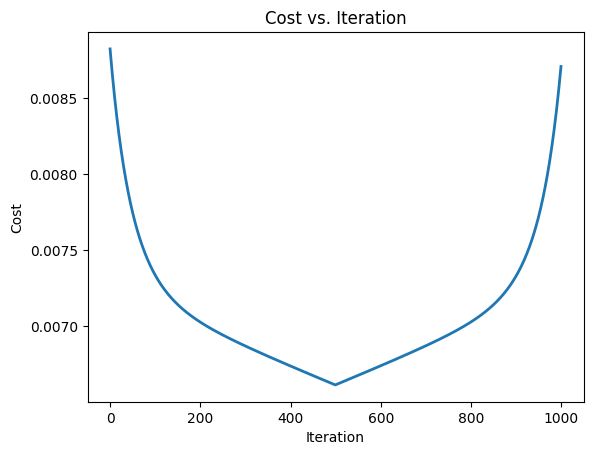

In [460]:
plotCost([NN])

The graph shows that subtracting the (scalar * Jacobian) gets the cost of the NN down (bringing it closer to the real world data), where as the inverse happens when you add it.

Intuitively, this makes sense as you are navigating a gradient that is a representation of the real world/model world difference. To get the two to be closer in outputs, you would need to move down the gradient by adjusting your position (using the slope derived from the Jacobian for each respective Weight matrix).

#### High Scalar

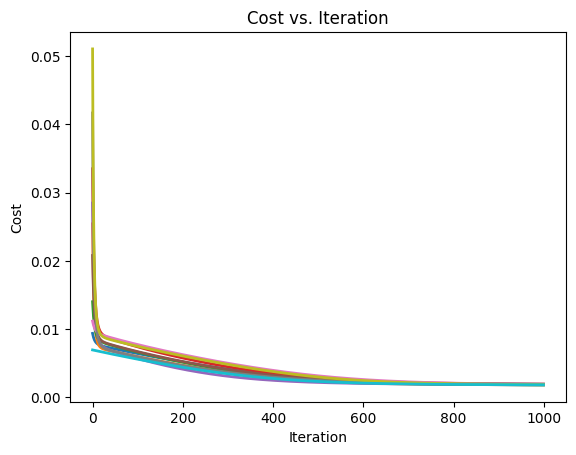

In [461]:
models = []
for _ in range(10):
    NN = Neural_Network('sig')
    trainIter(NN,X,y,1000,1)
    models.append(NN)
plotCost(models)

In [462]:
print(f"Accuracy (MSE) of each model:")
for i, model in enumerate(models, 1):
    print(f"Run #{i}: {model.computeAccuracy(X,y):.8f}")

Accuracy (MSE) of each model:
Run #1: 0.00121187
Run #2: 0.00122359
Run #3: 0.00122394
Run #4: 0.00128699
Run #5: 0.00125987
Run #6: 0.00127314
Run #7: 0.00127886
Run #8: 0.00127881
Run #9: 0.00124746
Run #10: 0.00122566


##### High Scalar - Cost Minima 0.001
![](Attachments/High%20-%200.001.png)

The effect of a high scalar is best described as a more intense "learning curve" where in (practically speaking) you are pushed further into a local minima. This means that your training times are much lower, but you get less iterations to check the directionality of your output (whether the outputs are starting to approximate the desired output).

#### Low Scalar

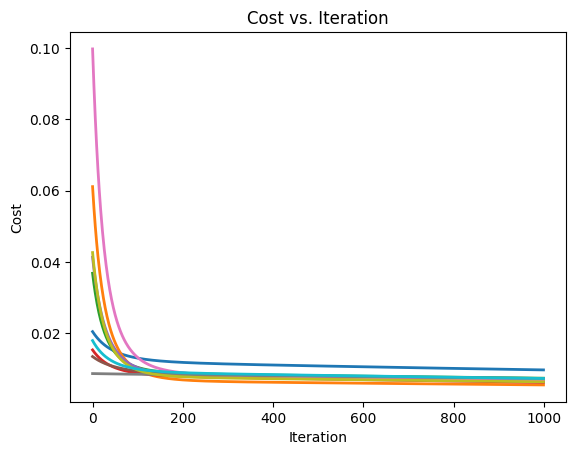

In [463]:
models = []
for _ in range(10):
    NN = Neural_Network('sig')
    trainIter(NN,X,y,1000,0.1)
    models.append(NN)
plotCost(models)

In [464]:
print(f"Accuracy (MSE) of each model:")
for i, model in enumerate(models, 1):
    print(f"Run #{i}: {model.computeAccuracy(X,y):.8f}")

Accuracy (MSE) of each model:
Run #1: 0.00648557
Run #2: 0.00367959
Run #3: 0.00493580
Run #4: 0.00415387
Run #5: 0.00436146
Run #6: 0.00435543
Run #7: 0.00462383
Run #8: 0.00488306
Run #9: 0.00425845
Run #10: 0.00488609


##### Low Scalar - Cost Minima 0.001
![](Attachments/Low%20-%200.001.png)

The effect of a low scalar is that you are able to slow down training to a more gentle curve where in (practically speaking) you are able to obtain more info early about the training progress and allowing you to redirect your training elsewhere if needed. Furthermore, you avoid any "rebounding" where you over adjust a weight and need to readjust it back (leading to more consistent training).

However, the downside of this approach is that (when using the Sigmoid function) the training time/iterations grows. While the High Scalar took ~100,000 iterations to reach the desires minima, the Low Scalar took ~175,000 iterations to do so.

## Part 2 - ReLU Function and Neural Nets

Defined in Part 1, the ReLU (Rectified Linear Unit) function returns the input into a node if the function becomes "activated" (like a neuron might with an action potential). This function is far more computationaly efficient and transmits more discrete data than the Sigmoid function does; however, if you are in need of a more binary output or some value between 0 and 1, the sigmoid still remains a strong option.

Furthermore, the ReLU function avoids an issue that is present in the Sigmoid function in which the compression of the inputs to a value between 0 and 1 causes intensity to be lost, leading to the "vanishing gradient problem" which impacts the training needed for weight matricies.

### Comparing the Training Functions

In [465]:
# Parameters (Comparisons)
n = 10
scalar = [0.0025, 0.0025] # Sig, ReLU
acc = 0.005
maxIter = 10000

In [466]:
dataCompare = {}

dataSig = []
rtSig = []
for _ in range(n):
    start = time.time()
    NNSig = Neural_Network('sig')
    NNSig = trainAcc(NNSig,X,y,acc,scalar[0],maxIter)
    stop = time.time()
    runtime = stop - start
    
    final_acc = NNSig.computeAccuracy(X,y)
    dataSig.append((runtime, final_acc))
    rtSig.append(runtime)
dataCompare['sig'] = dataSig
rtSigFmt = list(map(lambda x:((x*1000)//0.01)/100, rtSig))
rtSigAvg = ((sum(rtSigFmt)/len(rtSig))//0.01)/100

In [467]:
dataRelu = []
rtRelu = []
for _ in range(n):
    start = time.time()
    NNRelu = Neural_Network('relu')
    NNRelu = trainAcc(NNRelu,X,y,acc,scalar[1],maxIter)
    stop = time.time()
    runtime = stop - start
    
    final_acc = NNRelu.computeAccuracy(X,y)
    dataRelu.append((runtime, final_acc))
    rtRelu.append(runtime)
dataCompare['relu'] = dataRelu
rtReluFmt = list(map(lambda x:((x*1000)//0.01)/100, rtRelu))
rtReluAvg = ((sum(rtReluFmt)/len(rtRelu))//0.01)/100

In [468]:
print("Time for ~0.005 Accuracy (MSE)")
print("------------------------------")

print(f"Sigmoid (avg) = {rtSigAvg} ms")
print(f"Max: {max(rtSigFmt)} ms | Min: {min(rtSigFmt)} ms")
#for i in range(len(rtSigFmt)):
    #print(f" - #{i+1}: {rtSigFmt[i]} ms")

print(f"\nReLU (avg) = {rtReluAvg} ms")
print(f"Max: {max(rtReluFmt)} ms | Min: {min(rtReluFmt)} ms")
#for i in range(len(rtReluFmt)):
    #print(f" - #{i+1}: {rtReluFmt[i]} ms")

Time for ~0.005 Accuracy (MSE)
------------------------------
Sigmoid (avg) = 1728.38 ms
Max: 2160.12 ms | Min: 0.34 ms

ReLU (avg) = 1049.54 ms
Max: 1951.73 ms | Min: 415.93 ms


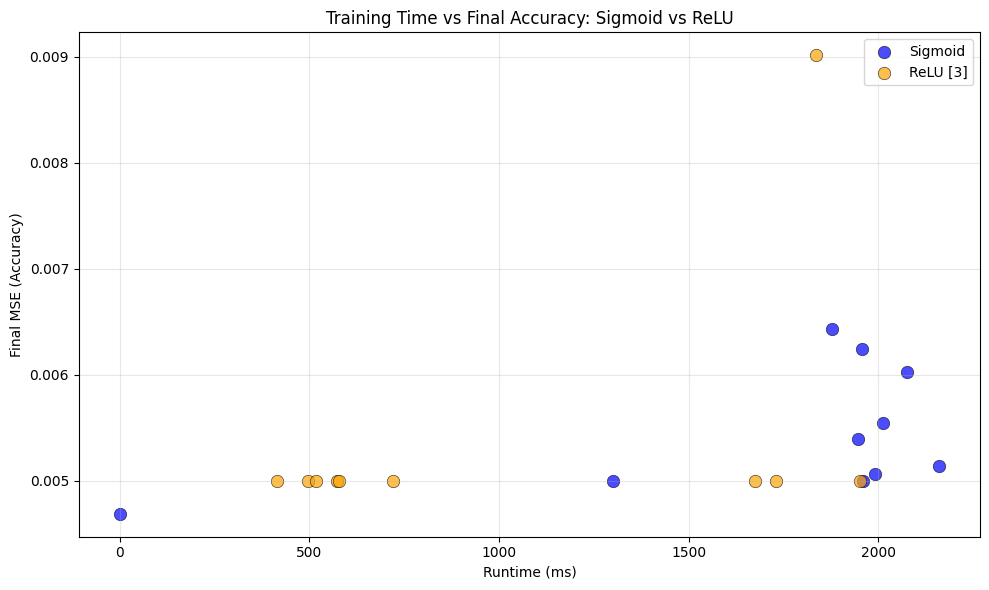

In [469]:
plotData(dataCompare)

#### Accuracy vs. Runtime - 0.001 Scalar and 0.001 Accuracy (MSE)
![](Attachments/Scatter%20-%200.001%20MSE%20(Variable%20Scalar).png)

The graphs you see, the recently generated and the prior generation, are examples of what it looks like when you train the two types of models (Sigmoid vs. ReLU) with with the same scalars, each aiming for 0.001 Accuracy (MSE). Notably, when you allow for the same scalar, the time difference starts to show. Building on prior information about low vs. high scalar, the tradeoffs here become very apparent as lower scalars are more efficient with ReLU than Sigmoid functions.

### Expanded Neural Nets
With the switch to ReLU function training, we can explore more expanded neural net models with no major performance hit. Here is how node count impacts training times (sticking with 0.005 MSE from now on):

In [470]:
dataRelu3 = []
rtRelu3 = []
for _ in range(n):
    start = time.time()
    NNRelu3 = Neural_Network('relu',[3,3])
    NNRelu3 = trainAcc(NNRelu3,X,y,acc,scalar[1],maxIter)
    stop = time.time()
    runtime = stop - start
    
    final_acc = NNRelu3.computeAccuracy(X,y)
    dataRelu3.append((runtime, final_acc))
    rtRelu3.append(runtime)
dataCompare['relu3'] = dataRelu3
rtRelu3Fmt = list(map(lambda x:((x*1000)//0.01)/100, rtRelu3))
rtRelu3Avg = ((sum(rtRelu3Fmt)/len(rtRelu3))//0.01)/100

In [471]:
print("Time for ~0.005 Accuracy (MSE)")
print("------------------------------")

print(f"ReLU [3] (avg) = {rtReluAvg} ms")
print(f"Max: {max(rtReluFmt)} ms | Min: {min(rtReluFmt)} ms")
#for i in range(len(rtReluFmt)):
    #print(f" - #{i+1}: {rtReluFmt[i]} ms")

print(f"\nReLU [3,3] (avg) = {rtRelu3Avg} ms")
print(f"Max: {max(rtRelu3Fmt)} ms | Min: {min(rtRelu3Fmt)} ms")
#for i in range(len(rtRelu3Fmt)):
    #print(f" - #{i+1}: {rtRelu3Fmt[i]} ms")

Time for ~0.005 Accuracy (MSE)
------------------------------
ReLU [3] (avg) = 1049.54 ms
Max: 1951.73 ms | Min: 415.93 ms

ReLU [3,3] (avg) = 1885.8 ms
Max: 3789.99 ms | Min: 0.07 ms


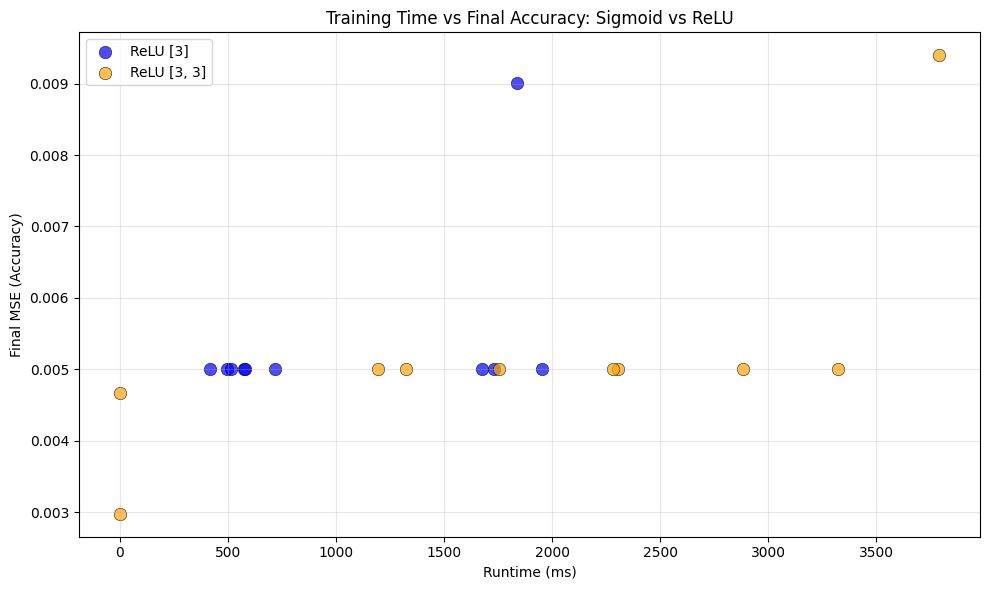

In [472]:
plotData(dataCompare, ['relu', 'relu3'])

What we observe here is the difference between the one hidden layer and two hidden layer models (with the same number of nodes) have a notably different training time. We find that this is the case due to the necessary complexity found in the the addition of new nodes and (more importantly) a whole new weight matrix to propgate with.

In [473]:
dataRelu10 = []
rtRelu10 = []
for _ in range(n):
    start = time.time()
    NNRelu10 = Neural_Network('relu',[3,10])
    NNRelu10 = trainAcc(NNRelu10,X,y,acc,scalar[1],maxIter)
    stop = time.time()
    runtime = stop - start
    
    final_acc = NNRelu3.computeAccuracy(X,y)
    dataRelu10.append((runtime, final_acc))
    rtRelu10.append(runtime)
dataCompare['relu10'] = dataRelu10
rtRelu10Fmt = list(map(lambda x:((x*1000)//0.01)/100, rtRelu10))
rtRelu10Avg = ((sum(rtRelu10Fmt)/len(rtRelu10))//0.01)/100

In [474]:
print("Time for ~0.005 Accuracy (MSE)")
print("------------------------------")

print(f"ReLU [3,3] (avg) = {rtRelu3Avg} ms")
print(f"Max: {max(rtRelu3Fmt)} ms | Min: {min(rtRelu3Fmt)} ms")
#for i in range(len(rtReluFmt)):
    #print(f" - #{i+1}: {rtReluFmt[i]} ms")

print(f"\nReLU [3,10] (avg) = {rtRelu10Avg} ms")
print(f"Max: {max(rtRelu10Fmt)} ms | Min: {min(rtRelu10Fmt)} ms")
#for i in range(len(rtRelu3Fmt)):
    #print(f" - #{i+1}: {rtRelu3Fmt[i]} ms")

Time for ~0.005 Accuracy (MSE)
------------------------------
ReLU [3,3] (avg) = 1885.8 ms
Max: 3789.99 ms | Min: 0.07 ms

ReLU [3,10] (avg) = 1980.93 ms
Max: 3951.86 ms | Min: 117.89 ms


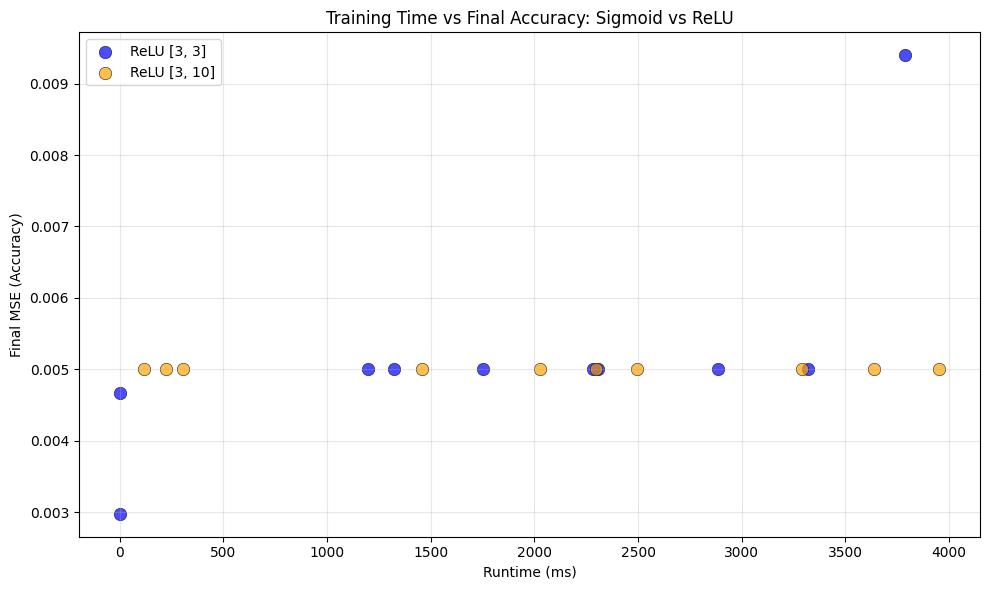

In [475]:
plotData(dataCompare, ['relu3', 'relu10'])